In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

In [2]:
import pandas as pd
import numpy as np

# Step 1: Load the dataset
file_path = "iyer.txt"
df = pd.read_csv(file_path, sep="\t", header=None)

# Step 2: Drop the first column (row index)
df = df.drop(columns=0)

# Step 3: Split features (X) and labels (y)
X = df.iloc[:, 1:].values  # All columns except label
y = df.iloc[:, 0].values   # Label column

# Step 4: Filter out label -1 (unlabeled/invalid rows)
mask = y != -1
X = X[mask]
y = y[mask]

y = y - 1

print("Labels shifted to start from 0")
print("Updated unique classes:", np.unique(y))

# Step 5: Confirm structure
print("Iyer Dataset Ready")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))


Labels shifted to start from 0
Updated unique classes: [0 1 2 3 4 5 6 7 8 9]
Iyer Dataset Ready
X shape: (484, 12)
y shape: (484,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Storage for results
accuracies = []
f1_scores = []
auc_scores = []

# Repeat 3 times
for seed in range(3):
    print(f"\nRun {seed+1}/3")
    
    # 1. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    
    # 2. Hyperparameter Tuning (GridSearchCV)
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.2]
    }
    
    model = XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=10,
        tree_method='hist'
    )
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=3,
        verbose=0,
        n_jobs=2
    )
    
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    # 3. Retrain best model on full train split
    best_model.fit(X_train, y_train)
    
    # 4. Evaluation
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    
    print(f"Accuracy: {acc:.4f} | F1 Score (macro): {f1:.4f} | AUC (macro, OvR): {auc:.4f}")
    
    accuracies.append(acc)
    f1_scores.append(f1)
    auc_scores.append(auc)

#Final Report
print("\n Final 3-run Report:")
print(f"Mean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Mean F1 Score (macro): {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Mean AUC (macro, OvR): {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")



Run 1/3
Accuracy: 0.8425 | F1 Score (macro): 0.7972 | AUC (macro, OvR): 0.9828

Run 2/3
Accuracy: 0.8493 | F1 Score (macro): 0.8013 | AUC (macro, OvR): 0.9757

Run 3/3
Accuracy: 0.7808 | F1 Score (macro): 0.6942 | AUC (macro, OvR): 0.9621

 Final 3-run Report:
Mean Accuracy: 0.8242 ± 0.0308
Mean F1 Score (macro): 0.7642 ± 0.0495
Mean AUC (macro, OvR): 0.9735 ± 0.0086


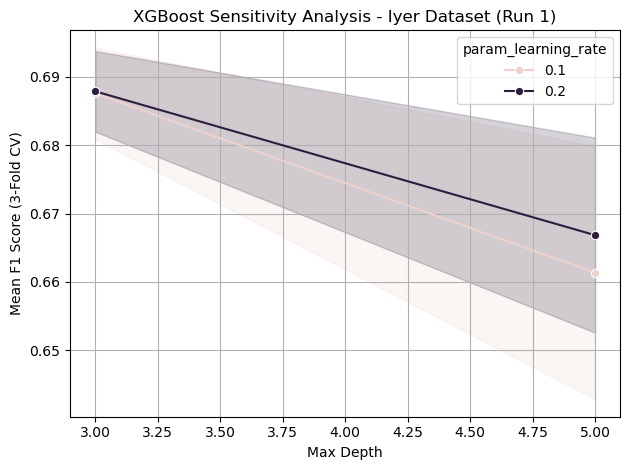

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert GridSearchCV results into a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot F1 score vs max_depth, colored by learning_rate
sns.lineplot(
    data=results_df,
    x="param_max_depth",
    y="mean_test_score",
    hue="param_learning_rate",
    marker="o"
)
plt.title("XGBoost Sensitivity Analysis - Iyer Dataset (Run 1)")
plt.xlabel("Max Depth")
plt.ylabel("Mean F1 Score (3-Fold CV)")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/figures/xgb_iyer_sensitivity_plot.png", dpi=300)
plt.show()


In [5]:
from sklearn.metrics import classification_report

# Class names: 0–9 (after label shifting from 1–10)
class_names = [f"Class {i}" for i in range(10)]

print("\nClassification Report (Test Set - Last Run):")
print(classification_report(y_test, y_pred, target_names=class_names))



Classification Report (Test Set - Last Run):
              precision    recall  f1-score   support

     Class 0       0.73      0.90      0.81        30
     Class 1       0.85      0.89      0.87        44
     Class 2       0.57      0.40      0.47        10
     Class 3       0.82      0.69      0.75        13
     Class 4       0.50      0.50      0.50         2
     Class 5       0.90      0.90      0.90        10
     Class 6       0.60      0.75      0.67         4
     Class 7       0.83      0.79      0.81        19
     Class 8       0.75      0.50      0.60         6
     Class 9       0.67      0.50      0.57         8

    accuracy                           0.78       146
   macro avg       0.72      0.68      0.69       146
weighted avg       0.78      0.78      0.77       146



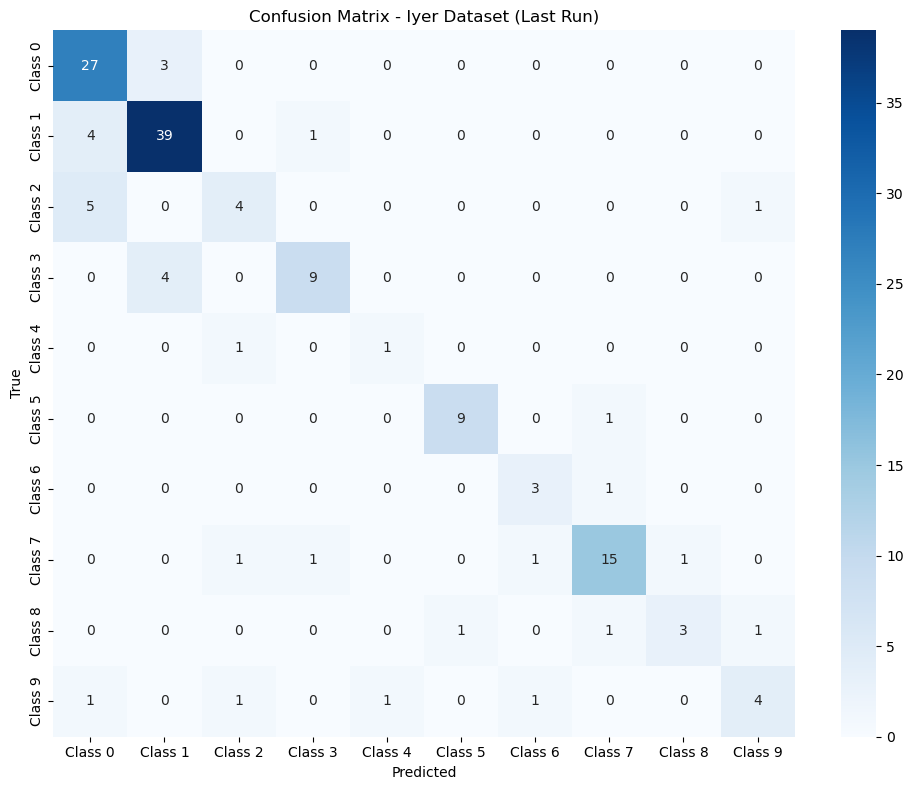

In [6]:
from sklearn.metrics import confusion_matrix

# Confusion matrix (optional)
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Iyer Dataset (Last Run)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
